In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

In [2]:
adata_cancer = sc.read_h5ad('cancercell_kinetics_adata_add.h5ad')

In [3]:
dolken_scslam = {
    'Actb': 3.0533, 'B2m': 21.1779, 'Btg2': 0.3726, 'Canx': 7.0179,
    'Ccnd1': 2.7426, 'Cox6c': 14.9183, 'Cxcl1': 0.6956, 'Ddit4': 0.5213, 
    'Dusp1': 0.3746, 'Eef1a1': 11.9793, 'Egr1': 0.8480, 'Hif1a': 1.8565, 
    'Hnrnpa1': 5.1248, 'Hsp90ab1': 3.6426, 'Id2': 0.2580, 'Ier2': 0.5421, 
    'Ier3': 0.3088, 'Junb': 0.4387, 'Ldha': 9.7411, 'Myc': 0.2843, 
    'Nr4a1': 0.2466, 'Rpl13': 13.4251, 'Rpl13a': 10.3931, 'Rps18': 2.7627, 
    'Sod1': 16.2508, 'Top2a': 2.7245, 'Tpt1': 19.2701, 'Tuba1a': 5.2446, 
    'Tuba1b': 5.1018, 'Tubb5': 2.1570
}

# 增加了 Junb: 1.0707
timelapse = {
    'Actb': 17.0519, 'B2m': 9.0347, 'Canx': 9.7124, 'Ccnd1': 4.7863,
    'Cxcl1': 2.5765, 'Eef1a1': 13.2178, 'Egr1': 0.7032, 'Hif1a': 4.4415,
    'Hnrnpa1': 5.4892, 'Hsp90ab1': 12.1660, 'Id2': 1.7967, 'Ier2': 0.7185,
    'Ier3': 0.7083, 'Junb': 1.0707, 'Ldha': 17.6761, 'Myc': 0.9533,
    'Rps18': 4.4951, 'Top2a': 5.9094, 'Tpt1': 10.9136, 'Tuba1b': 5.1151, 
    'Tubb5': 6.7837
}

# 增加了 Junb: 1.8742
slam_mes = {
    'Actb': 12.9616, 'Canx': 6.192, 'Ccnd1': 3.3699, 'Cox6c': 17.4082,
    'Ddit4': 1.5352, 'Dusp1': 1.3354, 'Eef1a1': 13.3736, 'Egr1': 1.5356, 
    'Hif1a': 3.1428, 'Hnrnpa1': 8.5956, 'Hsp90ab1': 7.3746, 'Id2': 1.9881, 
    'Ier2': 2.0555, 'Ier3': 2.3582, 'Junb': 1.8742, 'Ldha': 9.7710, 
    'Myc': 0.9439, 'Nr4a1': 1.6304, 'Rpl13': 12.7339, 'Rpl13a': 5.4144, 
    'Rps18': 12.9495, 'Sod1': 13.1923, 'Top2a': 3.6282, 'Tpt1': 13.6860, 
    'Tuba1a': 8.0951, 'Tuba1b': 7.1857, 'Tubb5': 6.1660
}

scnt_pluripotent = {
    'Actb': 8.56, 'Btg2': 1.74, 'Canx': 4.11, 'Ddit4': 1.83, 
    'Eef1a1': 6.79, 'Hnrnpa1': 4.57, 'Hsp90ab1': 5.67, 'Ldha': 5.09, 
    'Rpl13a': 2.98, 'Sod1': 5.89, 'Top2a': 2.8, 'Tuba1a': 4.46, 
    'Tuba1b': 3.34, 'Tubb5': 3.53
}

koszinowski = {
    'Btg2': 0.0919, 'Ccnd1': 2.6337, 'Cxcl1': 1.110955254, 'Dusp1': 1.0355
}

selbach = {
    'Actb': 11.21, 'B2m': 16.05, 'Cox6c': 13.98, 'Hnrnpa1': 9.18,
    'Tubb5': 13.73
}

gene_list = [
    'Actb', 'B2m', 'Btg2', 'Canx', 'Ccnd1', 'Cox6c', 'Cxcl1', 'Ddit4', 
    'Dusp1', 'Eef1a1', 'Egr1', 'Hif1a', 'Hnrnpa1', 'Hsp90ab1', 'Id2', 
    'Ier2', 'Ier3', 'Junb', 'Ldha', 'Myc', 'Nr4a1', 'Rpl13', 'Rpl13a', 
    'Rps18', 'Sod1', 'Top2a', 'Tpt1', 'Tuba1a', 'Tuba1b', 'Tubb5'
]
ref_data_map = {
    'Dolken (scSLAM)': dolken_scslam,
    'TimeLapse-seq': timelapse,
    'SLAM-seq (mES)': slam_mes,
    'scNT-seq': scnt_pluripotent,
    'Koszinowski': koszinowski,
    'Selbach (4sU)': selbach,
}


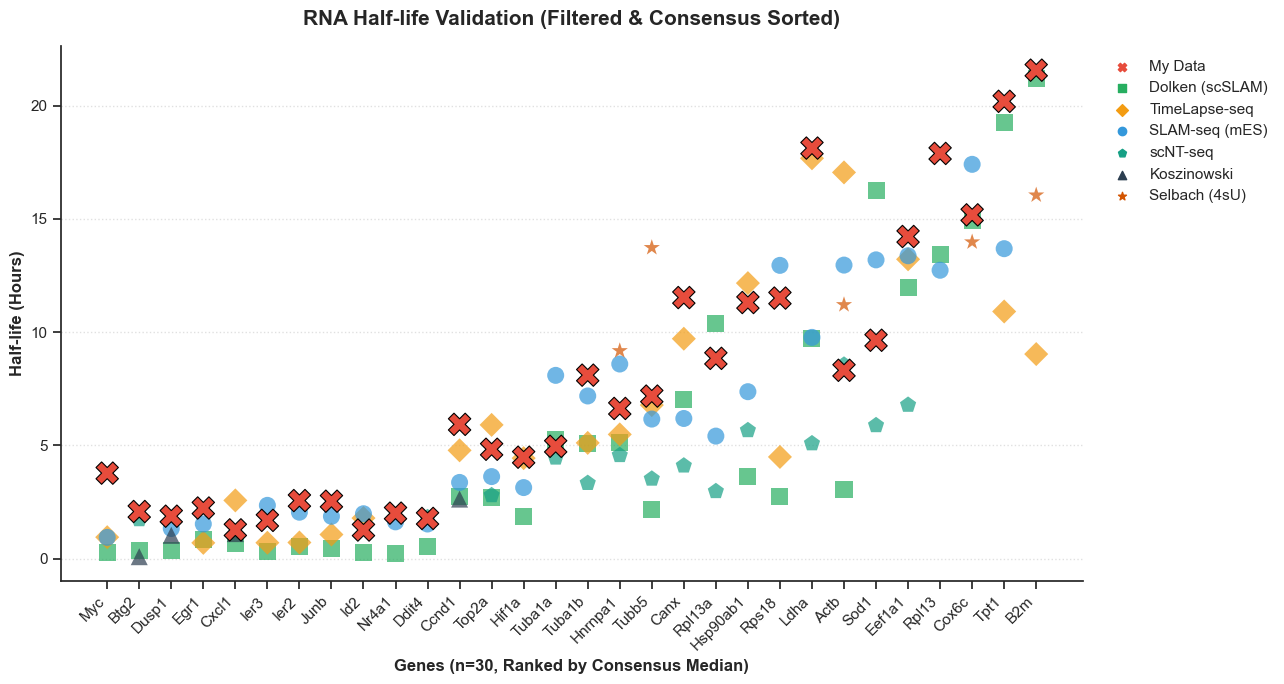

In [4]:
genes_in_my_data = [g for g in gene_list if g in adata_cancer.var_names]
hl_col = 'half_life_gene_strict' 
my_data_series = adata_cancer.var.loc[genes_in_my_data, hl_col]

df_ranking = pd.DataFrame(ref_data_map)
df_ranking['My Data'] = my_data_series

df_ranking = df_ranking.dropna(subset=['My Data'], how='all').dropna(how='all')

consensus_median = df_ranking.median(axis=1)
sorted_genes = consensus_median.sort_values().index.tolist()

all_points = []
for g in sorted_genes:
    # mydata
    all_points.append({'Gene': g, 'Source': 'My Data', 'Val': my_data_series[g]})
    
    # ref data
    for name, data_dict in ref_data_map.items():
        if g in data_dict:
            all_points.append({'Gene': g, 'Source': name, 'Val': data_dict[g]})

df_all = pd.DataFrame(all_points)

df_all = df_all.dropna(subset=['Val'])

df_mine = df_all[df_all['Source'] == 'My Data']
df_others = df_all[df_all['Source'] != 'My Data']

#settings
custom_palette = {
    'My Data': '#E74C3C', 
    'Dolken (scSLAM)': '#27AE60', 
    'TimeLapse-seq': '#F39C12', 
    'SLAM-seq (mES)': '#3498DB', 
    'scNT-seq': '#16A085', 
    'Koszinowski': '#2C3E50', 
    'Selbach (4sU)': '#D35400'
}
custom_markers = {
    'My Data': 'X', 
    'Dolken (scSLAM)': 's', 
    'TimeLapse-seq': 'D', 
    'SLAM-seq (mES)': 'o', 
    'scNT-seq': 'p', 
    'Koszinowski': '^', 
    'Selbach (4sU)': '*'
}


plt.figure(figsize=(13, 7))
sns.set_theme(style="ticks")

sns.scatterplot(
    data=df_others, x='Gene', y='Val', hue='Source', style='Source',
    s=150, palette=custom_palette, markers=custom_markers,
    edgecolor='none', alpha=0.7, zorder=3
)

sns.scatterplot(
    data=df_mine, x='Gene', y='Val', hue='Source', style='Source',
    s=260, palette=custom_palette, markers=custom_markers,
    edgecolor='black', linewidth=0.8, alpha=1, zorder=5
)

# plt.yscale('log')
plt.title("RNA Half-life Validation (Filtered & Consensus Sorted)", fontsize=15, fontweight='bold', pad=15)
plt.ylabel("Half-life (Hours)", fontsize=12, fontweight='bold')
plt.xlabel(f"Genes (n={len(sorted_genes)}, Ranked by Consensus Median)", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
order = ['My Data'] + [l for l in by_label.keys() if l != 'My Data' and l != 'Source']

plt.legend(
    [by_label[l] for l in order if l in by_label], 
    [l for l in order if l in by_label],
    bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False
)

sns.despine()
# plt.savefig("comparison of hl.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

In [5]:
# calc strict half_life
df_external = pd.read_excel('bulk_SLAMseq_hl.xlsx') 
ref_data = df_external

exclude_samples = ['Label_NC_1', 'Label_NC_2']
adata_filtered = adata_cancer[~adata_cancer.obs['orig.ident'].isin(exclude_samples)].copy()
gene_summary = pd.DataFrame(index=adata_filtered.var_names)
var_calc_threshold = 3 
total_smooth_T = adata_filtered.layers['total_smooth']

# Loop through each remaining sample for calculation
for group in adata_filtered.obs['orig.ident'].unique():

    subset = adata_filtered[adata_filtered.obs['orig.ident'] == group]
    hl_matrix = subset.layers['half_life']
    hl_matrix[hl_matrix <= 0] = np.nan
    ts_subset = subset.layers['total_smooth']
    high_conf_mask = (ts_subset >= var_calc_threshold)
    hl_for_var = np.where(high_conf_mask, hl_matrix, np.nan)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        gene_summary[f'{group}_gene_hl'] = np.nanmean(hl_for_var, axis=0)

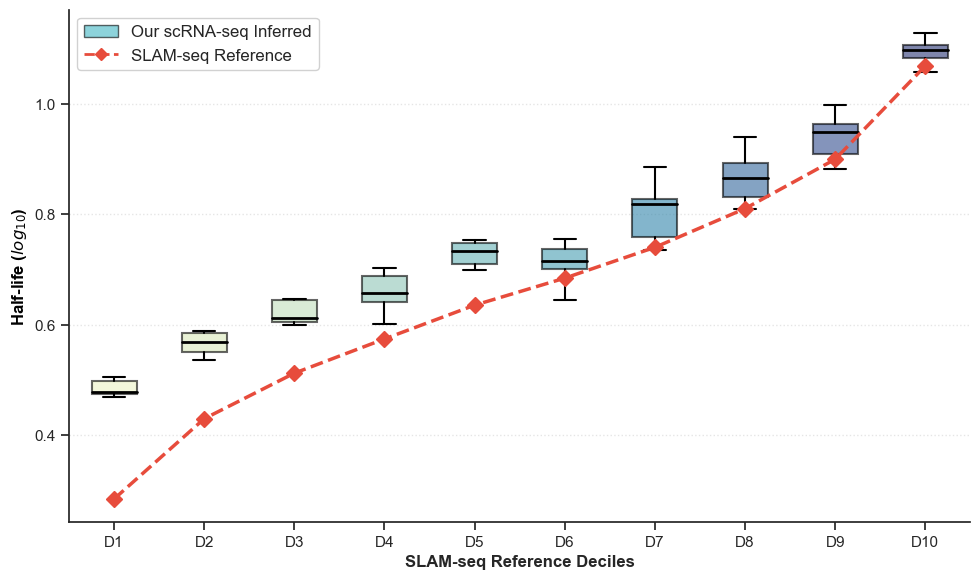

In [6]:
## Data Alignment, Binning, and Secondary Aggregation
sample_cols = [col for col in gene_summary.columns if '_gene_hl' in col]

merged = pd.concat([gene_summary[sample_cols], ref_data.set_index(ref_data.columns[0])['SLAM-seq_mES']], axis=1, join='inner').dropna()
merged = merged[(merged > 0).all(axis=1)]

merged['log_Ref'] = np.log10(merged['SLAM-seq_mES'])
merged['SLAM_bin_10'] = pd.qcut(merged['SLAM-seq_mES'], 10, labels=[f'D{i+1}' for i in range(10)])

# Calculate the median log10 reference value
ref_trend = merged.groupby('SLAM_bin_10', observed=True)['log_Ref'].median()
merged_long = merged.melt(id_vars=['SLAM_bin_10'], value_vars=sample_cols, var_name='Sample', value_name='Raw_HL')
merged_long['log_Mine'] = np.log10(merged_long['Raw_HL'])

sample_bin_means = merged_long.groupby(['SLAM_bin_10', 'Sample'], observed=True)['log_Mine'].median().reset_index()


# Plotting (Boxplot + Trend Line)
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.set_theme(style="ticks", font_scale=1.1)

sns.boxplot(
    data=sample_bin_means, 
    x='SLAM_bin_10', 
    y='log_Mine', 
    palette="YlGnBu", 
    width=0.5,
    showfliers=False,  
    boxprops=dict(alpha=0.6, edgecolor='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    ax=ax1,
    zorder=1              
)

ax1.plot(
    range(10), ref_trend.values, 
    color='#e74c3c', marker='D', markersize=8, 
    linestyle='--', linewidth=2.5, 
    zorder=5  
)

ax1.set_ylabel(r'Half-life ($log_{10}$)', fontweight='bold', color='black')
ax1.set_xlabel('SLAM-seq Reference Deciles', fontweight='bold')

legend_elements = [
    Patch(facecolor='#41b6c4', alpha=0.6, edgecolor='black', label='Our scRNA-seq Inferred'),
    Line2D([0], [0], color='#e74c3c', marker='D', linestyle='--', linewidth=2, label='SLAM-seq Reference')
]

ax1.legend(handles=legend_elements, loc='upper left', frameon=True, framealpha=0.9)

ax1.grid(axis='y', linestyle=':', alpha=0.5)
sns.despine(top=True, right=True) 
plt.tight_layout()
plt.show()